# Residential Subtype Classification

This notebook trains and evaluates a multiclass model for classifying residential buildings into their Level-2 subtypes. It performs feature selection, hyperparameter optimization, model comparison, and final model training.

**Input**
- Preprocessed residential-subtype training, validation, and test data.
- Candidate machine-learning features.

**Output**
- Selected features for residential subtype classification.
- Optimized multiclass models and evaluation results.
- Final trained residential subtype classifier.

In [ ]:
import numpy as np
import pandas as pd
import joblib
import os
import json
import warnings
import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay)
import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.utils.class_weight import compute_sample_weight


import optuna

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

np.random.seed(42)

ROOT_DIR  = '/fast/home/o-olajuyigbe/osm_project'
ML_DIR    = os.path.join(ROOT_DIR, 'data', 'ml_ready')
MODEL_DIR = os.path.join(ROOT_DIR, 'data', 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

# LEVEL Options: 'flat_l1', 'flat_l2', 'l0_res_binary', 'l1a_res_subtypes',
#          'l1b_ind_binary', 'l2a_ind_subtypes', 'l2b_comm_binary', 'l3a_comm_subtypes'
LEVEL = 'l1a_res_subtypes'

print(f"Training level: {LEVEL}")

Training level: l1a_res_subtypes


/fast/home/o-olajuyigbe/miniforge3/envs/osm_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
X_train, y_train = joblib.load(os.path.join(ML_DIR, f'{LEVEL}_train_raw.pkl'))
X_val,   y_val   = joblib.load(os.path.join(ML_DIR, f'{LEVEL}_val_raw.pkl'))
X_test,  y_test  = joblib.load(os.path.join(ML_DIR, f'{LEVEL}_test_raw.pkl'))
classes          = joblib.load(os.path.join(ML_DIR, f'{LEVEL}_classes.pkl'))
candidate_features = joblib.load(os.path.join(ML_DIR, 'candidate_features.pkl'))

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Classes : {classes}")

n_classes = len(np.unique(y_train))

# print class count fot trainin, test and validation sets
print("\nClass distribution in training set:")
print(np.bincount(y_train))
print("\nClass distribution in validation set:")
print(np.bincount(y_val))
print("\nClass distribution in test set:")
print(np.bincount(y_test))

X_train : (2929004, 110)
X_val   : (172402, 110)
X_test  : (344749, 110)
Classes : ['MFH' 'SFH' 'TH']

Class distribution in training set:
[1249264 1402086  277654]

Class distribution in validation set:
[73893 82110 16399]

Class distribution in test set:
[147407 164720  32622]


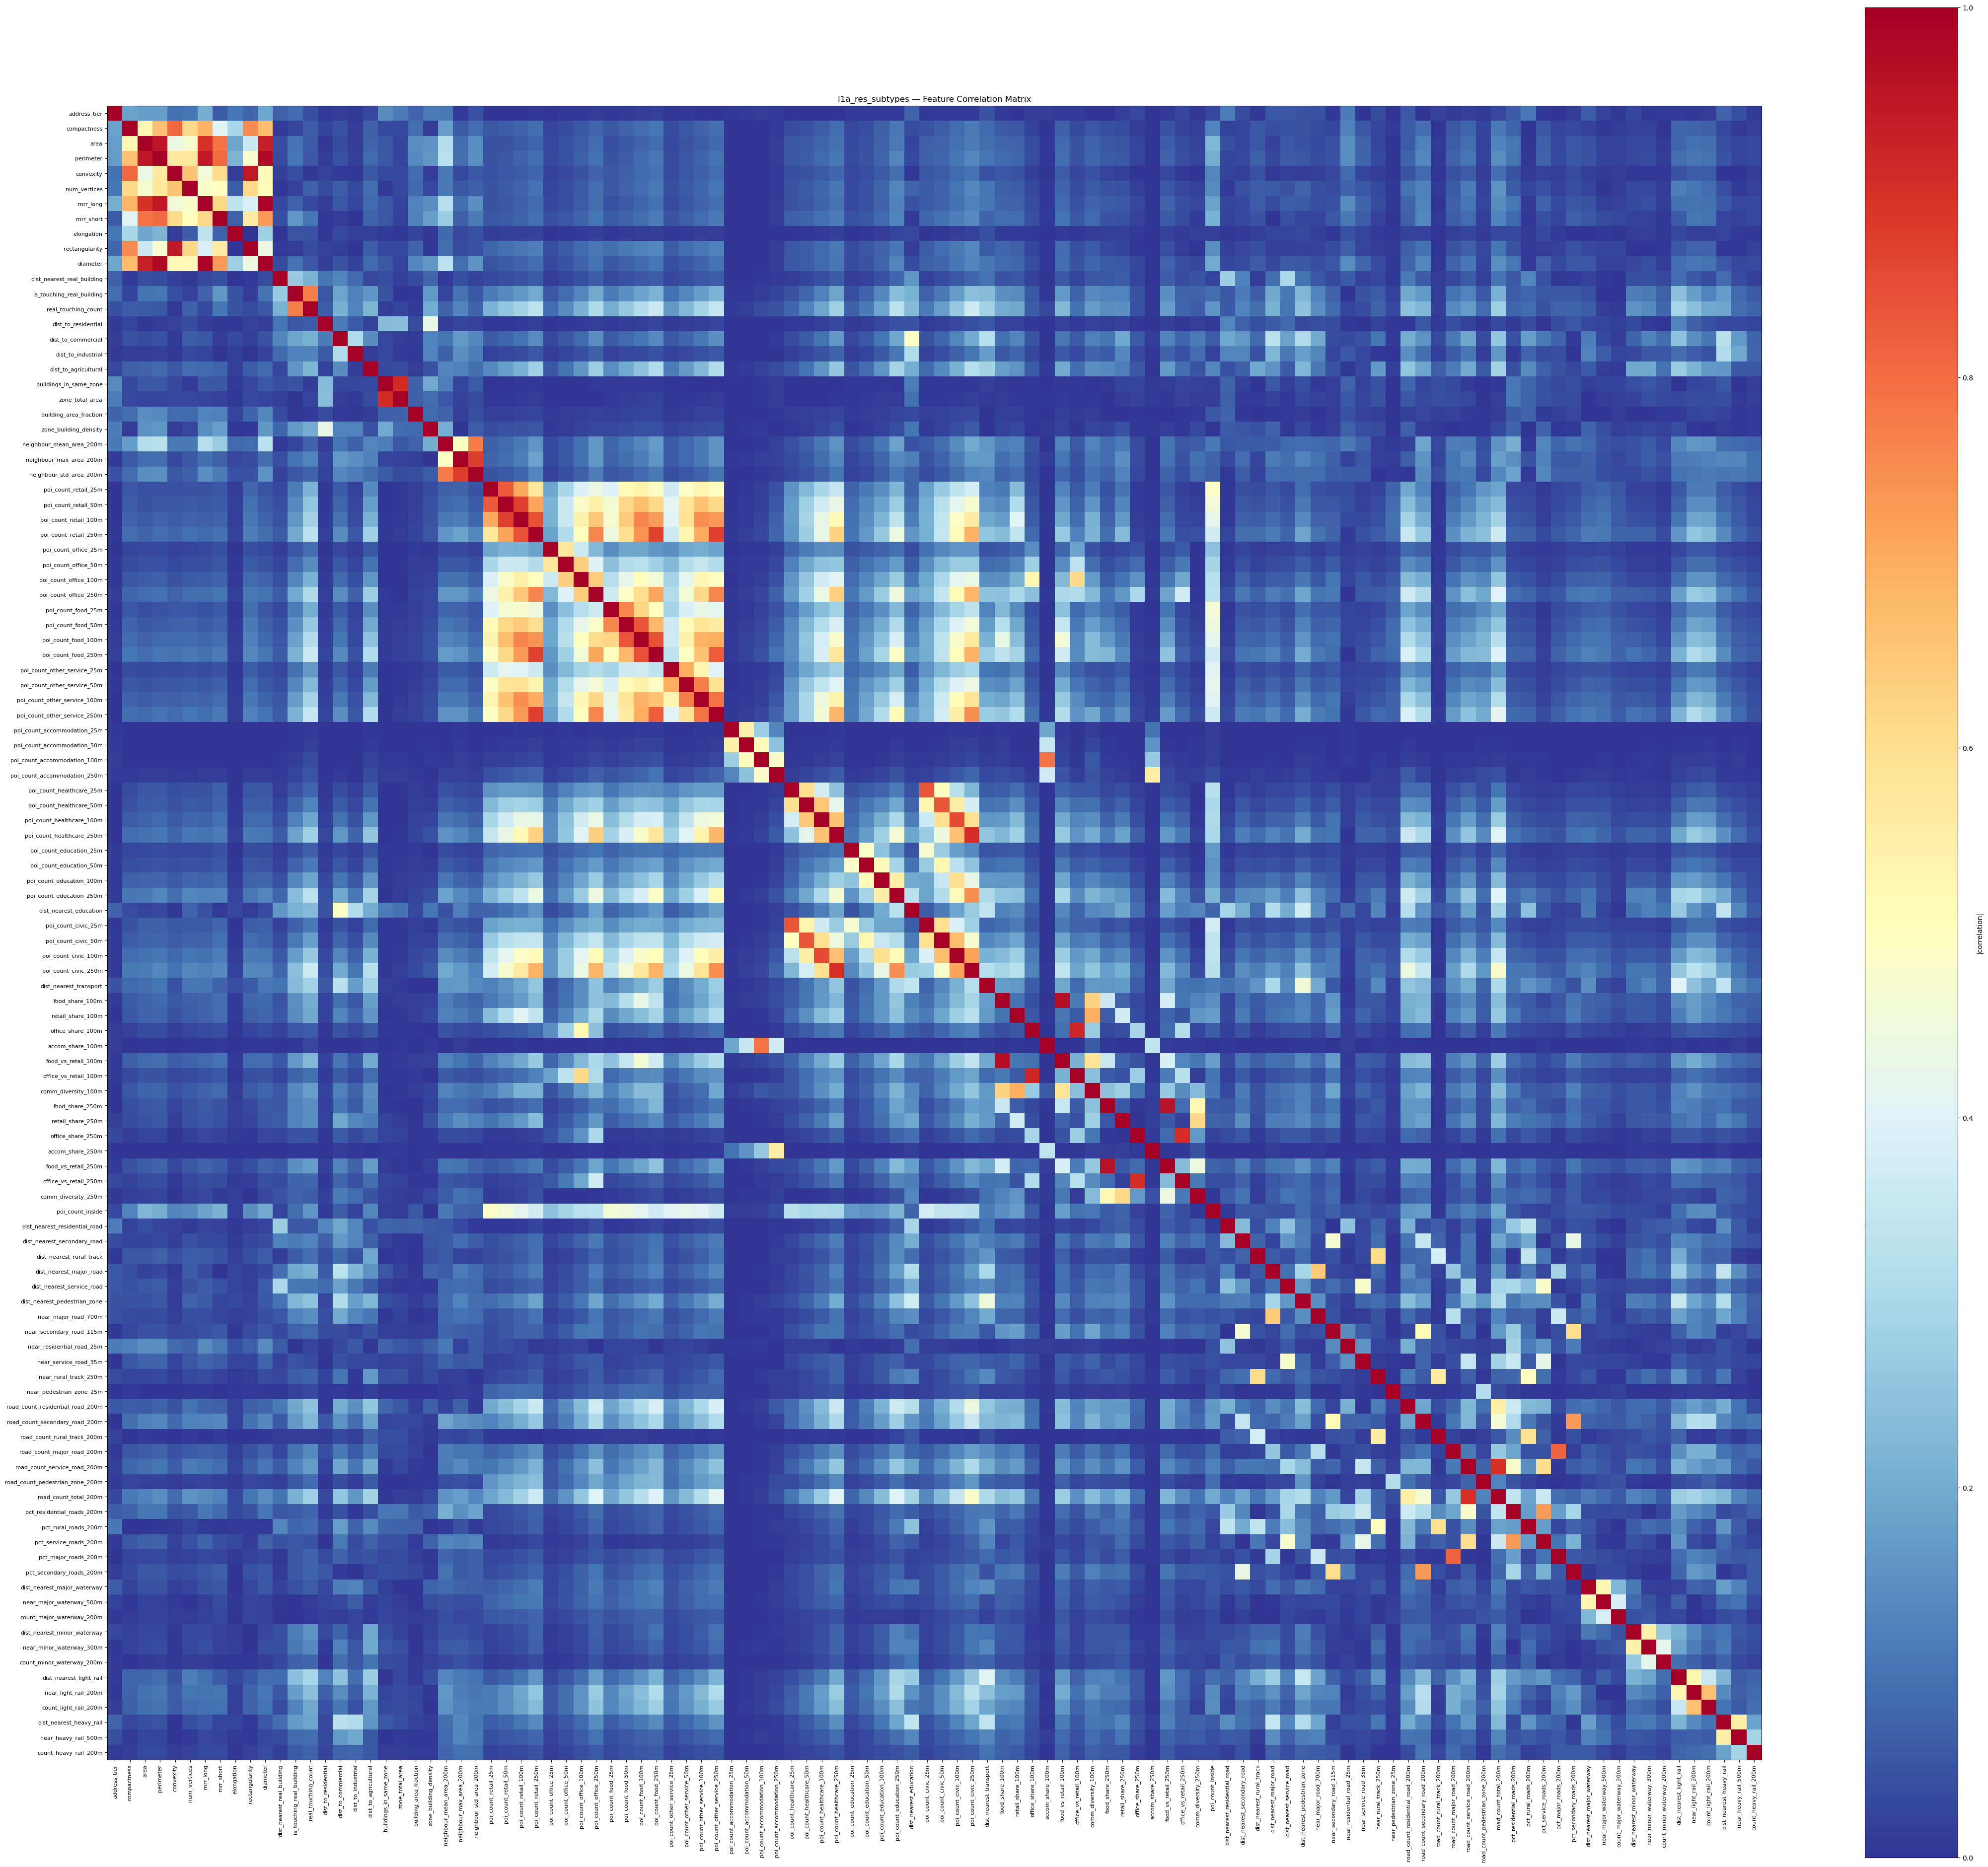

In [3]:
# Correlation Heatmap

corr_matrix = X_train[candidate_features].corr().abs()

fig, ax = plt.subplots(figsize=(max(8, len(candidate_features)*0.4), max(6, len(candidate_features)*0.35)))
im = ax.imshow(corr_matrix, cmap='RdYlBu_r', vmin=0, vmax=1)
ax.set_xticks(range(len(candidate_features)))
ax.set_yticks(range(len(candidate_features)))
ax.set_xticklabels(candidate_features, rotation=90, fontsize=8)
ax.set_yticklabels(candidate_features, fontsize=8)
fig.colorbar(im, ax=ax, label='|correlation|')
ax.set_title(f'{LEVEL} — Feature Correlation Matrix')
plt.tight_layout()
plt.show()


Class labels and their corresponding class names:
Class 0: MFH
Class 1: SFH
Class 2: TH
Excluded features (correlation <= 0.7 with all other features):
['address_tier', 'num_vertices', 'elongation', 'dist_nearest_real_building', 'dist_to_residential', 'dist_to_commercial', 'dist_to_industrial', 'dist_to_agricultural', 'building_area_fraction', 'zone_building_density', 'poi_count_office_25m', 'poi_count_office_50m', 'poi_count_office_100m', 'poi_count_other_service_25m', 'poi_count_accommodation_25m', 'poi_count_accommodation_50m', 'poi_count_accommodation_250m', 'poi_count_education_25m', 'poi_count_education_50m', 'poi_count_education_100m', 'dist_nearest_education', 'dist_nearest_transport', 'retail_share_100m', 'comm_diversity_100m', 'retail_share_250m', 'accom_share_250m', 'comm_diversity_250m', 'poi_count_inside', 'dist_nearest_residential_road', 'dist_nearest_secondary_road', 'dist_nearest_rural_track', 'dist_nearest_major_road', 'dist_nearest_service_road', 'dist_nearest_pedest

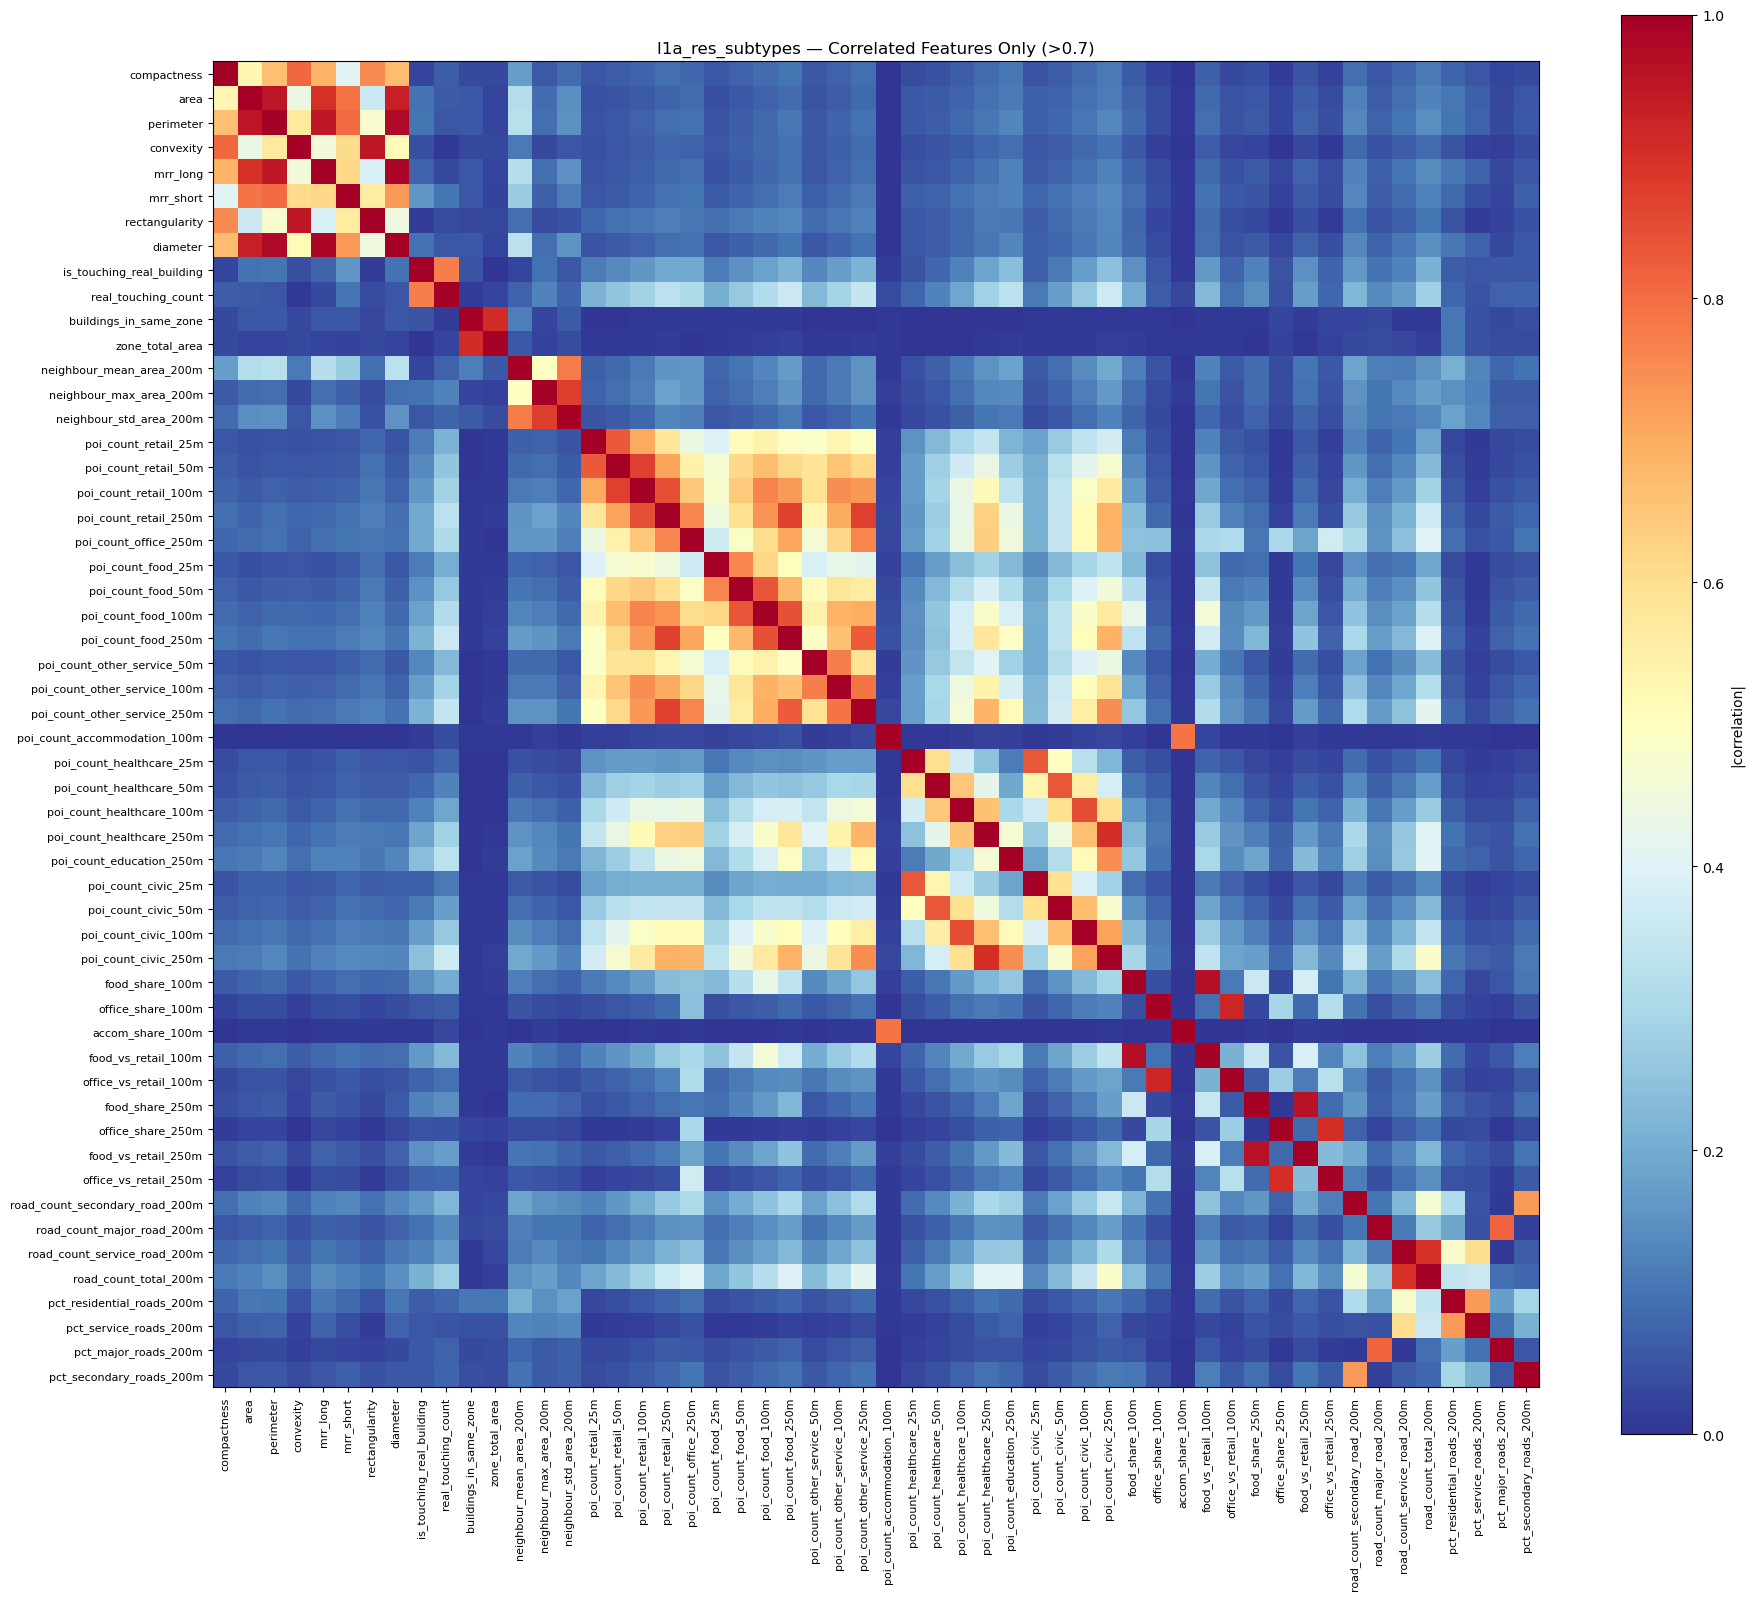

In [4]:
# too many features to view, only show features with correlation above a certain threshold
# check whicc class correspond sto posl_label 0 and 1
print("\nClass labels and their corresponding class names:")
for idx, class_name in enumerate(classes):
    print(f"Class {idx}: {class_name}")
    
FILTER_THRESHOLD = 0.7  # lower bar just for what gets INCLUDED in the plot


# Keep only features that have at least one other-feature correlation above FILTER_THRESHOLD
np.fill_diagonal(corr_matrix.values, 0)  # ignore self-correlation
has_strong_corr = corr_matrix.max(axis=1) > FILTER_THRESHOLD
plot_features = corr_matrix.index[has_strong_corr].tolist()

# print features not included in the plot
excluded_features = corr_matrix.index[~has_strong_corr].tolist()
print(f"Excluded features (correlation <= {FILTER_THRESHOLD} with all other features):")
print(excluded_features)

print(f"{len(plot_features)} / {len(candidate_features)} features have a correlation > {FILTER_THRESHOLD} with something else")

corr_subset = X_train[plot_features].corr().abs()

fig, ax = plt.subplots(figsize=(max(8, len(plot_features)*0.35), max(6, len(plot_features)*0.3)))
im = ax.imshow(corr_subset, cmap='RdYlBu_r', vmin=0, vmax=1)
ax.set_xticks(range(len(plot_features))); ax.set_xticklabels(plot_features, rotation=90, fontsize=8)
ax.set_yticks(range(len(plot_features))); ax.set_yticklabels(plot_features, fontsize=8)
fig.colorbar(im, ax=ax, label='|correlation|')
ax.set_title(f'{LEVEL} — Correlated Features Only (>{FILTER_THRESHOLD})')
plt.tight_layout()
plt.show()

Excluded features (correlation <= 0.9 with all other features):
['address_tier', 'compactness', 'num_vertices', 'mrr_short', 'elongation', 'dist_nearest_real_building', 'is_touching_real_building', 'real_touching_count', 'dist_to_residential', 'dist_to_commercial', 'dist_to_industrial', 'dist_to_agricultural', 'building_area_fraction', 'zone_building_density', 'neighbour_mean_area_200m', 'neighbour_max_area_200m', 'neighbour_std_area_200m', 'poi_count_retail_25m', 'poi_count_retail_50m', 'poi_count_retail_100m', 'poi_count_retail_250m', 'poi_count_office_25m', 'poi_count_office_50m', 'poi_count_office_100m', 'poi_count_office_250m', 'poi_count_food_25m', 'poi_count_food_50m', 'poi_count_food_100m', 'poi_count_food_250m', 'poi_count_other_service_25m', 'poi_count_other_service_50m', 'poi_count_other_service_100m', 'poi_count_other_service_250m', 'poi_count_accommodation_25m', 'poi_count_accommodation_50m', 'poi_count_accommodation_100m', 'poi_count_accommodation_250m', 'poi_count_health

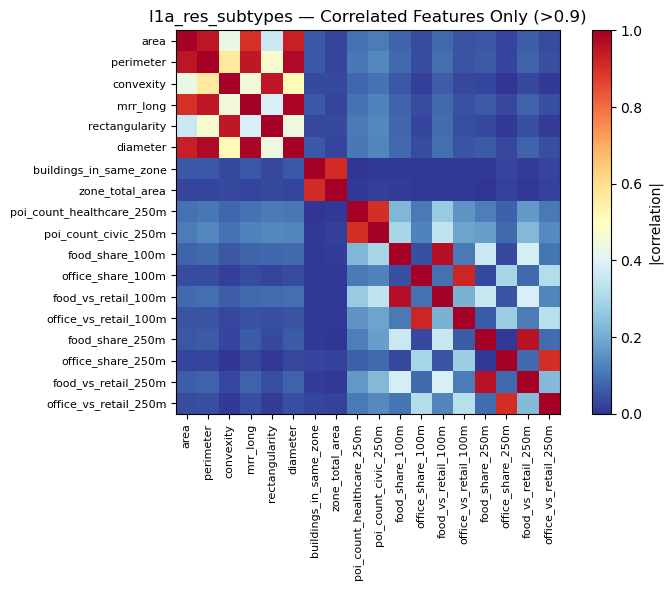

In [5]:

FILTER_THRESHOLD = 0.9  # lower bar just for what gets INCLUDED in the plot


# Keep only features that have at least one other-feature correlation above FILTER_THRESHOLD
np.fill_diagonal(corr_matrix.values, 0)  # ignore self-correlation
has_strong_corr = corr_matrix.max(axis=1) > FILTER_THRESHOLD
plot_features = corr_matrix.index[has_strong_corr].tolist()

# print features not included in the plot
excluded_features = corr_matrix.index[~has_strong_corr].tolist()
print(f"Excluded features (correlation <= {FILTER_THRESHOLD} with all other features):")
print(excluded_features)

print(f"{len(plot_features)} / {len(candidate_features)} features have a correlation > {FILTER_THRESHOLD} with something else")

corr_subset = X_train[plot_features].corr().abs()

fig, ax = plt.subplots(figsize=(max(8, len(plot_features)*0.35), max(6, len(plot_features)*0.3)))
im = ax.imshow(corr_subset, cmap='RdYlBu_r', vmin=0, vmax=1)
ax.set_xticks(range(len(plot_features))); ax.set_xticklabels(plot_features, rotation=90, fontsize=8)
ax.set_yticks(range(len(plot_features))); ax.set_yticklabels(plot_features, fontsize=8)
fig.colorbar(im, ax=ax, label='|correlation|')
ax.set_title(f'{LEVEL} — Correlated Features Only (>{FILTER_THRESHOLD})')
plt.tight_layout()
plt.show()

In [ ]:
# Ranked List of Correlated Pairs
CORR_THRESHOLD = 0.90

pairs = []
for i, c1 in enumerate(candidate_features):
    for c2 in candidate_features[i+1:]:
        r = corr_matrix.loc[c1, c2]
        if r > CORR_THRESHOLD:
            pairs.append((c1, c2, round(r, 3)))

pairs_df = pd.DataFrame(pairs, columns=['feature_1', 'feature_2', 'abs_corr']).sort_values('abs_corr', ascending=False)
print(f"{len(pairs_df)} pairs above {CORR_THRESHOLD}:\n")
pairs_df

12 pairs above 0.9:



,feature_1,feature_2,abs_corr
5,mrr_long,diameter,0.987
3,perimeter,diameter,0.977
8,food_share_100m,food_vs_retail_100m,0.968
10,food_share_250m,food_vs_retail_250m,0.958
0,area,perimeter,0.950
2,perimeter,mrr_long,0.946
4,convexity,rectangularity,0.946
1,area,diameter,0.933
9,office_share_100m,office_vs_retail_100m,0.919
6,buildings_in_same_zone,zone_total_area,0.908


In [ ]:
CORR_DROP = ['perimeter', 'diameter', 'food_vs_retail_100m', 'food_vs_retail_250m',
'rectangularity', 'office_vs_retail_100m', 'dist_nearest_building', 'office_vs_retail_250m',
'touching_building_count', 'poi_count_healthcare_250m', 'is_touching_building', 'zone_total_area'
]

kept_after_corr = [c for c in candidate_features if c not in CORR_DROP]
print(f"Dropped {len(CORR_DROP)} by hand: {CORR_DROP}")
print(f"Remaining: {len(kept_after_corr)} / {len(candidate_features)}")

Dropped 12 by hand: ['perimeter', 'diameter', 'food_vs_retail_100m', 'food_vs_retail_250m', 'rectangularity', 'office_vs_retail_100m', 'dist_nearest_building', 'office_vs_retail_250m', 'touching_building_count', 'poi_count_healthcare_250m', 'is_touching_building', 'zone_total_area']
Remaining: 101 / 110


Training until validation scores don't improve for 100 rounds
[500]	train's multi_logloss: 0.364442	val's multi_logloss: 0.372444
[1000]	train's multi_logloss: 0.341259	val's multi_logloss: 0.353487
[1500]	train's multi_logloss: 0.324778	val's multi_logloss: 0.340659
[2000]	train's multi_logloss: 0.310683	val's multi_logloss: 0.329844
[2500]	train's multi_logloss: 0.298619	val's multi_logloss: 0.320985
Did not meet early stopping. Best iteration is:
[2500]	train's multi_logloss: 0.298619	val's multi_logloss: 0.320985

BASELINE VAL PERFORMANCE — l1a_res_subtypes  (101 features)
Macro F1    : 0.8455
Weighted F1 : 0.8719

              precision    recall  f1-score   support

         MFH     0.8990    0.8572    0.8776     73893
         SFH     0.8530    0.9230    0.8866     82110
          TH     0.8699    0.6946    0.7724     16399

    accuracy                         0.8731    172402
   macro avg     0.8739    0.8249    0.8455    172402
weighted avg     0.8743    0.8731    0.8719    

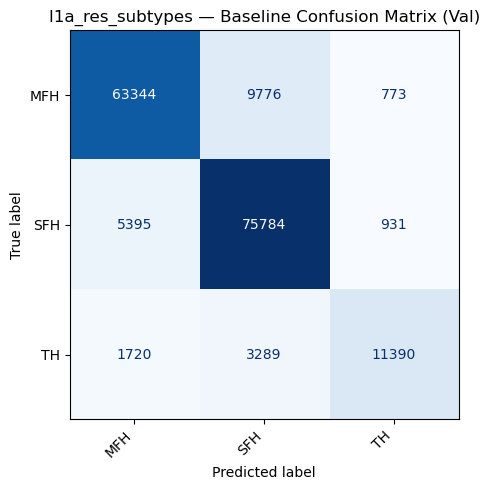

In [ ]:
baseline_params = dict(
    n_estimators=2500, learning_rate=0.05, n_jobs=-1,
    random_state=42, verbosity=-1, importance_type='gain'
)
if n_classes == 2:
    lgb_baseline = lgb.LGBMClassifier(objective='binary', eval_metric='binary_logloss', **baseline_params)
else:
    lgb_baseline = lgb.LGBMClassifier(objective='multiclass', num_class=n_classes, eval_metric='multi_logloss', **baseline_params)

baseline_model = lgb_baseline

lgb_baseline.fit(
    X_train[kept_after_corr], y_train,
    eval_set=[(X_train[kept_after_corr], y_train), (X_val[kept_after_corr], y_val)],
    eval_names=['train', 'val'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=500),   # prints progress every 500 rounds
    ]
)
gain_importance = pd.Series(baseline_model.feature_importances_, index=kept_after_corr).sort_values(ascending=False)
y_val_pred = baseline_model.predict(X_val[kept_after_corr])

avg_type = 'macro' if n_classes > 2 else 'binary'
baseline_macro_f1    = f1_score(y_val, y_val_pred, average='macro')
baseline_weighted_f1 = f1_score(y_val, y_val_pred, average='weighted')

print(f"\n{'='*60}")
print(f"BASELINE VAL PERFORMANCE — {LEVEL}  ({len(kept_after_corr)} features)")
print(f"{'='*60}")
print(f"Macro F1    : {baseline_macro_f1:.4f}")
print(f"Weighted F1 : {baseline_weighted_f1:.4f}\n")

target_names = classes if n_classes > 2 else None
print(classification_report(y_val, y_val_pred, target_names=target_names, digits=4))

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_val, y_val_pred)
disp_labels = classes if n_classes > 2 else ['neg', 'pos']
ConfusionMatrixDisplay(cm, display_labels=disp_labels).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'{LEVEL} — Baseline Confusion Matrix (Val)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


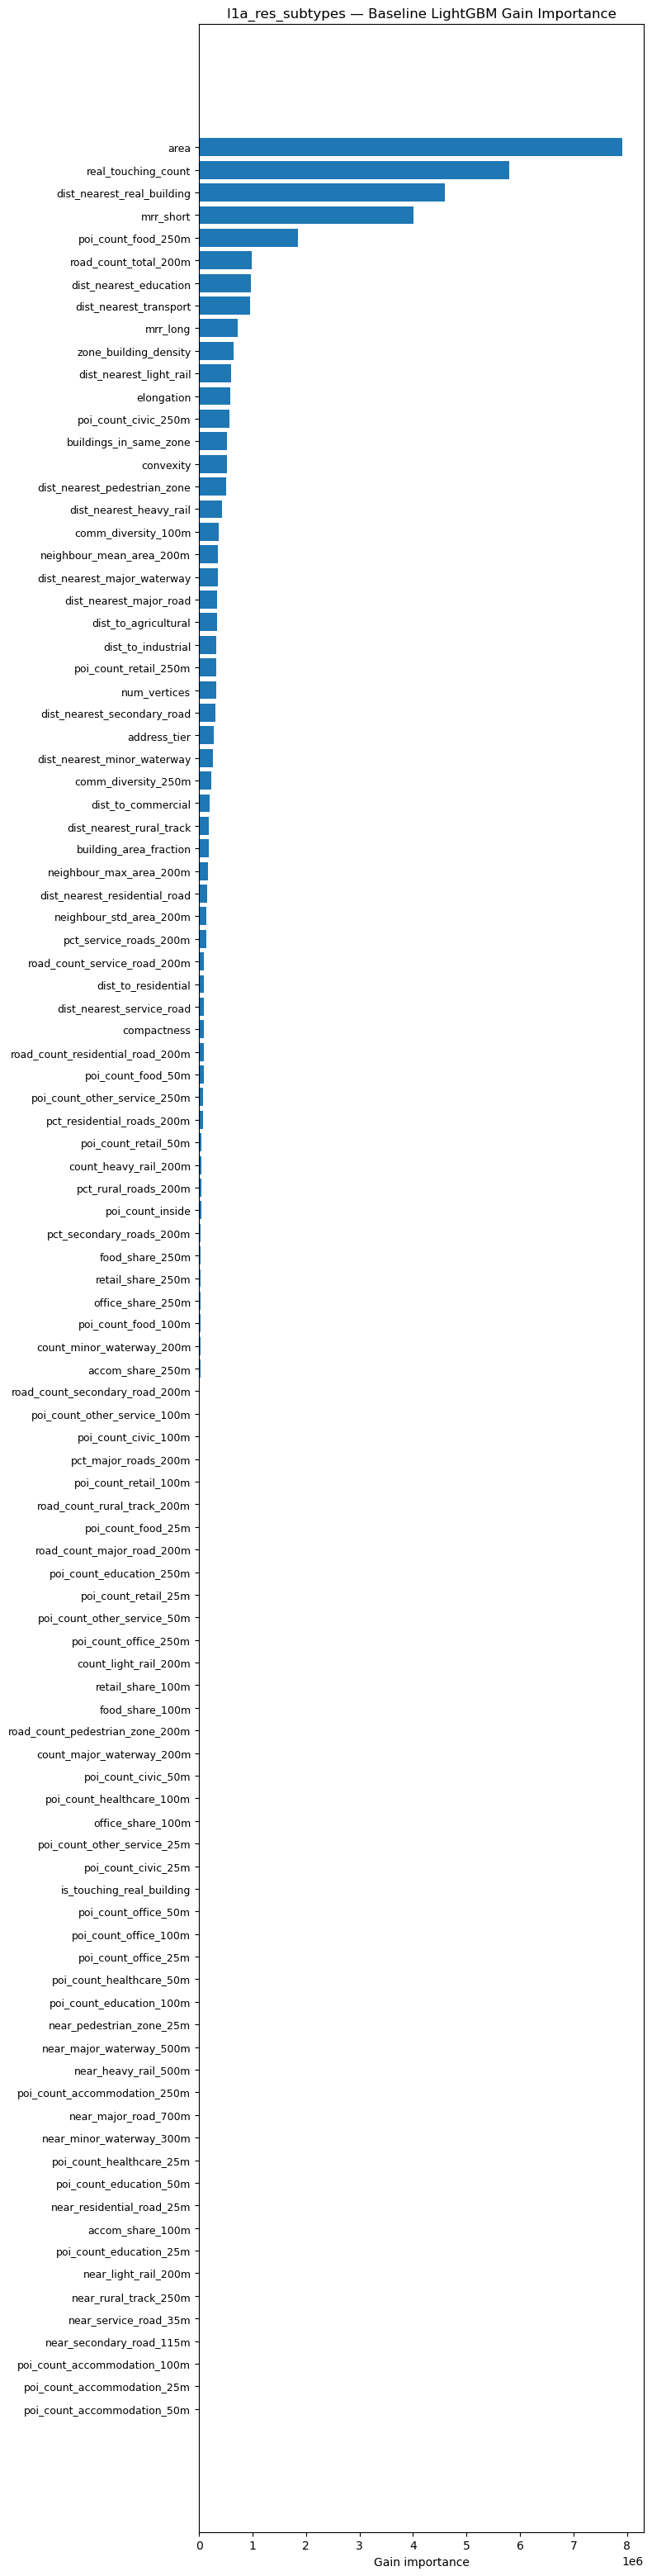

In [9]:
gain_importance = pd.Series(baseline_model.feature_importances_, index=kept_after_corr).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, len(kept_after_corr)*0.3 + 1))
ax.barh(range(len(gain_importance)), gain_importance.values[::-1])
ax.set_yticks(range(len(gain_importance)))
ax.set_yticklabels(gain_importance.index[::-1], fontsize=9)
ax.set_xlabel('Gain importance')
ax.set_title(f'{LEVEL} — Baseline LightGBM Gain Importance')
plt.tight_layout()
plt.show()

[0]	validation_0-mlogloss:0.90305	validation_1-mlogloss:0.90381
[500]	validation_0-mlogloss:0.37018	validation_1-mlogloss:0.37878
[1000]	validation_0-mlogloss:0.34448	validation_1-mlogloss:0.35735
[1500]	validation_0-mlogloss:0.32629	validation_1-mlogloss:0.34289
[2000]	validation_0-mlogloss:0.31159	validation_1-mlogloss:0.33150
[2499]	validation_0-mlogloss:0.29804	validation_1-mlogloss:0.32110

Stopped at iteration: 2499

BASELINE VAL PERFORMANCE — l1a_res_subtypes  (101 features)
Macro F1    : 0.8467
Weighted F1 : 0.8726

              precision    recall  f1-score   support

         MFH     0.8997    0.8568    0.8777     73893
         SFH     0.8541    0.9236    0.8875     82110
          TH     0.8671    0.7003    0.7748     16399

    accuracy                         0.8737    172402
   macro avg     0.8736    0.8269    0.8467    172402
weighted avg     0.8749    0.8737    0.8726    172402



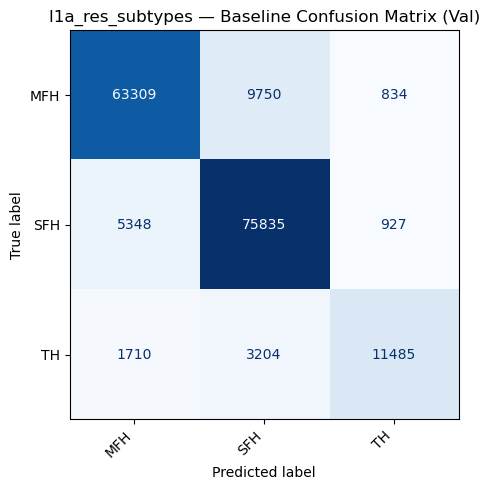

In [ ]:
#  XGBoost Baseline 
xgb_eval_metric = 'logloss' if n_classes == 2 else 'mlogloss'

xgb_params = dict(
    n_estimators=2500,
    learning_rate=0.05,
    n_jobs=-1, random_state=42,
    eval_metric=xgb_eval_metric,
    early_stopping_rounds=50,
)
if n_classes == 2:
    xgb_baseline = xgb.XGBClassifier(objective='binary:logistic', **xgb_params)
else:
    xgb_baseline = xgb.XGBClassifier(objective='multi:softprob', num_class=n_classes, **xgb_params)

xgb_baseline.fit(
    X_train[kept_after_corr], y_train,
    eval_set=[(X_train[kept_after_corr], y_train), (X_val[kept_after_corr], y_val)],
    verbose=500
)

print(f"\nStopped at iteration: {xgb_baseline.best_iteration}")
y_val_pred = xgb_baseline.predict(X_val[kept_after_corr])

avg_type = 'macro' if n_classes > 2 else 'binary'
xgb_macro_f1    = f1_score(y_val, y_val_pred, average='macro')
xgb_weighted_f1 = f1_score(y_val, y_val_pred, average='weighted')

print(f"\n{'='*60}")
print(f"BASELINE VAL PERFORMANCE — {LEVEL}  ({len(kept_after_corr)} features)")
print(f"{'='*60}")
print(f"Macro F1    : {xgb_macro_f1:.4f}")
print(f"Weighted F1 : {xgb_weighted_f1:.4f}\n")

target_names = classes if n_classes > 2 else None
print(classification_report(y_val, y_val_pred, target_names=target_names, digits=4))

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_val, y_val_pred)
disp_labels = classes if n_classes > 2 else ['neg', 'pos']
ConfusionMatrixDisplay(cm, display_labels=disp_labels).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'{LEVEL} — Baseline Confusion Matrix (Val)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
# ── XGBoost gain importance — compare ranking against LightGBM's ──
xgb_importance = pd.Series(
    xgb_baseline.get_booster().get_score(importance_type='gain'),
    name='xgb_gain'
)
xgb_importance = xgb_importance.sort_values(ascending=False)

comparison = pd.DataFrame({
    'lightgbm_rank': gain_importance.rank(ascending=False),
    'xgboost_rank' : xgb_importance.reindex(gain_importance.index).rank(ascending=False)
}).sort_values('lightgbm_rank')
print("\nTop features — rank agreement between LightGBM and XGBoost:")
comparison.head(20)


Top features — rank agreement between LightGBM and XGBoost:


,lightgbm_rank,xgboost_rank
area,1.0,2.0
real_touching_count,2.0,1.0
dist_nearest_real_building,3.0,4.0
mrr_short,4.0,5.0
poi_count_food_250m,5.0,3.0
road_count_total_200m,6.0,9.0
dist_nearest_education,7.0,17.0
dist_nearest_transport,8.0,23.0
mrr_long,9.0,18.0
zone_building_density,10.0,30.0


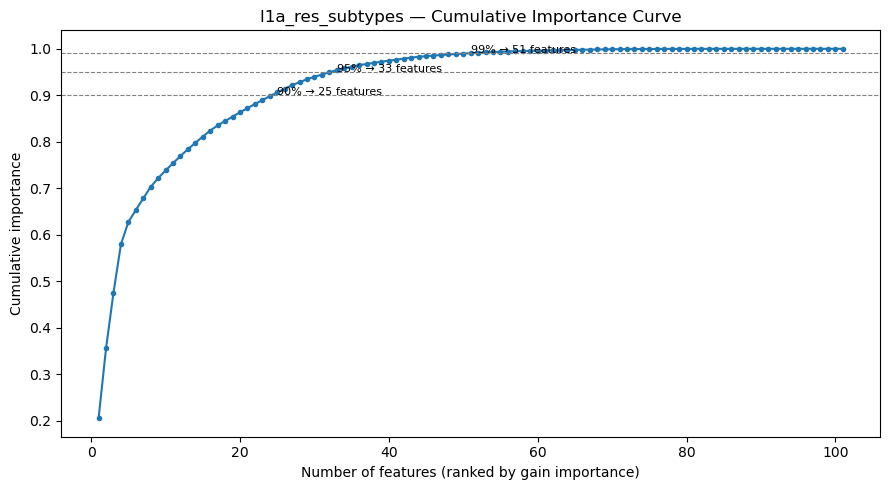

In [ ]:
# Cumulative Importance 
cum_importance = gain_importance.cumsum() / gain_importance.sum()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, len(cum_importance)+1), cum_importance.values, marker='o', markersize=3)
for pct in [0.90, 0.95, 0.99]:
    ax.axhline(pct, linestyle='--', color='gray', linewidth=0.8)
    n_at_pct = (cum_importance <= pct).sum() + 1
    ax.annotate(f'{int(pct*100)}% → {n_at_pct} features', xy=(n_at_pct, pct), fontsize=8)
ax.set_xlabel('Number of features (ranked by gain importance)')
ax.set_ylabel('Cumulative importance')
ax.set_title(f'{LEVEL} — Cumulative Importance Curve')
plt.tight_layout()
plt.show()

In [ ]:
# Reconciling LightGBM vs XGBoost rank disagreement
TOP_N = 51

lgb_top = set(comparison.sort_values('lightgbm_rank').head(TOP_N).index)
xgb_top = set(comparison.sort_values('xgboost_rank').head(TOP_N).index)

both_agree   = lgb_top & xgb_top   # strong keep — both models independently value these
lgb_only     = lgb_top - xgb_top   # LightGBM-favored 
xgb_only     = xgb_top - lgb_top   # XGBoost-favored 
neither      = set(comparison.index) - lgb_top - xgb_top   # both models agree these are weak

print(f"Both models rank in top {TOP_N}: {len(both_agree)}")
print(sorted(both_agree))
print(f"\nLightGBM-only top {TOP_N} (geometry-leaning?): {len(lgb_only)}")
print(sorted(lgb_only))
print(f"\nXGBoost-only top {TOP_N} (POI-count-leaning?): {len(xgb_only)}")
print(sorted(xgb_only))
print(f"\nBoth models agree these are weak — safe drop candidates: {len(neither)}")
print(sorted(neither))

union_selection = both_agree | lgb_only | xgb_only
selected_features = sorted(union_selection)  # convert to list for indexing
print(f"\nUnion selection: {len(union_selection)} features")

Both models rank in top 51: 40
['address_tier', 'area', 'building_area_fraction', 'buildings_in_same_zone', 'comm_diversity_100m', 'comm_diversity_250m', 'compactness', 'convexity', 'count_heavy_rail_200m', 'dist_nearest_education', 'dist_nearest_heavy_rail', 'dist_nearest_light_rail', 'dist_nearest_major_road', 'dist_nearest_major_waterway', 'dist_nearest_minor_waterway', 'dist_nearest_pedestrian_zone', 'dist_nearest_real_building', 'dist_nearest_residential_road', 'dist_nearest_secondary_road', 'dist_nearest_service_road', 'dist_nearest_transport', 'dist_to_agricultural', 'dist_to_industrial', 'elongation', 'mrr_long', 'mrr_short', 'neighbour_mean_area_200m', 'num_vertices', 'pct_service_roads_200m', 'poi_count_civic_250m', 'poi_count_food_250m', 'poi_count_food_50m', 'poi_count_inside', 'poi_count_other_service_250m', 'poi_count_retail_250m', 'poi_count_retail_50m', 'real_touching_count', 'road_count_service_road_200m', 'road_count_total_200m', 'zone_building_density']

LightGBM-onl

In [ ]:
# Before/After Sanity Check

model_full = type(baseline_model)(**baseline_model.get_params())
model_full.fit(X_train[candidate_features], y_train)
pred_full = model_full.predict(X_val[candidate_features])

model_reduced = type(baseline_model)(**baseline_model.get_params())
model_reduced.fit(X_train[selected_features], y_train)
pred_reduced = model_reduced.predict(X_val[selected_features])

avg = 'macro' if n_classes > 2 else 'binary'
f1_full    = f1_score(y_val, pred_full, average=avg)
f1_reduced = f1_score(y_val, pred_reduced, average=avg)

print(f"F1 (val) — full pool ({len(candidate_features)} feats)     : {f1_full:.4f}")
print(f"F1 (val) — selected  ({len(selected_features)} feats)      : {f1_reduced:.4f}")
print(f"Difference: {f1_reduced - f1_full:+.4f}")

F1 (val) — full pool (110 feats)     : 0.8466
F1 (val) — selected  (62 feats)      : 0.8465
Difference: -0.0001


In [ ]:
# Try more aggressive cuts
for n in [30, 40, 50, 60, 73]:
    trial_features = list(gain_importance.index[:n])
    model_trial = type(baseline_model)(**baseline_model.get_params())
    model_trial.fit(X_train[trial_features], y_train)
    pred_trial = model_trial.predict(X_val[trial_features])
    f1_trial = f1_score(y_val, pred_trial, average='macro' if n_classes > 2 else 'binary')
    print(f"N={n:>3}: F1={f1_trial:.4f}  (diff from full: {f1_trial - f1_full:+.4f})")

N= 30: F1=0.8442  (diff from full: -0.0024)
N= 40: F1=0.8475  (diff from full: +0.0009)
N= 50: F1=0.8465  (diff from full: -0.0001)
N= 60: F1=0.8463  (diff from full: -0.0003)
N= 73: F1=0.8459  (diff from full: -0.0006)


In [ ]:
joblib.dump(selected_features, os.path.join(MODEL_DIR, f'{LEVEL}_feature_cols.pkl'))

feature_cols = selected_features
X_train = X_train[selected_features].values
X_val   = X_val[selected_features].values
X_test  = X_test[selected_features].values

In [ ]:
# Evaluation Helper (used by every model)

def evaluate(model, X_val, y_val, X_test, y_test, classes, model_name, level, threshold=0.5):
    results = {}
    for split_name, X_sp, y_sp in [('val', X_val, y_val), ('test', X_test, y_test)]:
        
        y_pred = model.predict(X_sp).astype(int)

        report = classification_report(y_sp, y_pred, target_names=classes, output_dict=True)
        macro_f1 = f1_score(y_sp, y_pred, average='macro')
        weighted_f1 = f1_score(y_sp, y_pred, average='weighted')
        

        results[split_name] = {
            'macro_f1'   : round(macro_f1, 4),
            'weighted_f1': round(weighted_f1, 4),
            'report'     : report,
        }
        print(f"\n{model_name} — {split_name.upper()} (Decision Threshold: {threshold:.3f})")
        print(f"  Macro F1    : {macro_f1:.4f}")
        print(f"  Weighted F1 : {weighted_f1:.4f}")
        print(classification_report(y_sp, y_pred, target_names=classes, digits=4))

    y_pred_test = model.predict(X_test).astype(int)

    cm = confusion_matrix(y_test, y_pred_test)
    fig, ax = plt.subplots(figsize=(max(6, n_classes), max(5, n_classes-1)))
    ConfusionMatrixDisplay(cm, display_labels=classes).plot(ax=ax, colorbar=False)
    ax.set_title(f'{model_name} — {level} — Test Confusion Matrix')
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_DIR, f'{level}_{model_name}_confusion.png'), dpi=150)
    plt.show()

    return results


all_results = {}  # accumulates results from all models for comparison

In [ ]:
n_classes = len(classes)
minority_class_idx = pd.Series(y_train).value_counts().idxmin()
print(f"Minority class: {classes[minority_class_idx]} (index {minority_class_idx})")
print(f"Optimizing 2 objectives: macro F1 (overall balance) vs minority-class F1 (specific priority)")

def get_sample_weights(y, minority_boost=1.0):
    base_weights = compute_sample_weight(class_weight='balanced', y=y)
    class_counts_local = pd.Series(y).value_counts()
    minority_idx = class_counts_local.idxmin()
    boost_mask = (y == minority_idx)
    weights = base_weights.copy()
    weights[boost_mask] *= minority_boost
    return weights

Minority class: TH (index 2)
Optimizing 2 objectives: macro F1 (overall balance) vs minority-class F1 (specific priority)


In [ ]:
# Optuna Hyperparameter Optimization (Fast Subsampled Search)

N_TRIALS = 50
TUNING_FRACTION = 0.20
n_sub = int(len(X_train) * TUNING_FRACTION)

sss = StratifiedShuffleSplit(n_splits=1, train_size=n_sub, random_state=42)
sub_idx, _ = next(sss.split(X_train, y_train))
X_train_sub, y_train_sub = X_train[sub_idx], y_train[sub_idx]


print(f"Optimizing hyperparameters on a sample of {n_sub:,} rows for {n_classes} classes...")


def objective_lightgbm(trial):
    minority_boost = trial.suggest_float('minority_boost', 1.0, 5.0)
    sample_weights_sub = get_sample_weights(y_train_sub, minority_boost=minority_boost)

    params = {
        'objective': 'multiclass',
        'num_class': n_classes,
        'metric': 'multi_logloss',
        'boosting_type': 'gbdt',
        'n_estimators': 3000,
        'learning_rate': trial.suggest_float('learning_rate', 0.03, 0.12, log=True),
        'max_depth': -1, 
        'num_leaves': trial.suggest_int('num_leaves', 63, 255),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 500),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'min_split_gain': trial.suggest_float('min_split_gain', 1e-3, 1.0, log=True),
        'n_jobs': -1,
        'random_state': 42,
        'verbosity': -1
    }
    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_train_sub, y_train_sub,
        sample_weight=sample_weights_sub,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )
    preds = model.predict(X_val)
    f1_per_class = f1_score(y_val, preds, average=None)

    macro_f1    = f1_per_class.mean()
    minority_f1 = f1_per_class[minority_class_idx]

    # Store the full breakdown so you can inspect any trial later without retraining
    trial.set_user_attr('f1_per_class', f1_per_class.tolist())

    return macro_f1, minority_f1


def objective_xgboost(trial):
    minority_boost = trial.suggest_float('minority_boost', 1.0, 5.0)
    sample_weights_sub = get_sample_weights(y_train_sub, minority_boost=minority_boost)

    params = {
        'objective': 'multi:softprob',
        'num_class': n_classes,
        'eval_metric': 'mlogloss',
        'n_estimators': 3000,
        'learning_rate': trial.suggest_float('learning_rate', 0.03, 0.12, log=True),
        'max_depth': trial.suggest_int('max_depth', 5, 12), 
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'alpha': trial.suggest_float('alpha', 1e-3, 10.0, log=True),
        'lambda': trial.suggest_float('lambda', 1e-3, 10.0, log=True),
        'gamma': trial.suggest_float('gamma', 1e-3, 10.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 50, log=True),
        'tree_method': 'hist',
        'early_stopping_rounds': 50,
        'n_jobs': -1,
        'random_state': 42
    }
    model = xgb.XGBClassifier(**params)
    model.fit(
        X_train_sub, y_train_sub,
        sample_weight=sample_weights_sub,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    preds = model.predict(X_val)
    f1_per_class = f1_score(y_val, preds, average=None)

    macro_f1    = f1_per_class.mean()
    minority_f1 = f1_per_class[minority_class_idx]
    trial.set_user_attr('f1_per_class', f1_per_class.tolist())

    return macro_f1, minority_f1

# Run Multi-Objective Optimization

print("Optimizing LightGBM (multi-objective)...")
study_lgb_multi = optuna.create_study(directions=['maximize', 'maximize'])
study_lgb_multi.optimize(objective_lightgbm, n_trials=N_TRIALS, show_progress_bar=True)

print("\nOptimizing XGBoost (multi-objective)...")
study_xgb_multi = optuna.create_study(directions=['maximize', 'maximize'])
study_xgb_multi.optimize(objective_xgboost, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nLightGBM Pareto front: {len(study_lgb_multi.best_trials)} non-dominated trials")
print(f"XGBoost Pareto front : {len(study_xgb_multi.best_trials)} non-dominated trials")

Optimizing hyperparameters on a sample of 585,800 rows for 3 classes...
Optimizing LightGBM (multi-objective)...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [8:07:30<00:00, 585.02s/it]



Optimizing XGBoost (multi-objective)...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [2:42:56<00:00, 195.53s/it]


LightGBM Pareto front: 2 non-dominated trials
XGBoost Pareto front : 1 non-dominated trials


Number of trials on the Pareto front: 2
Trial with highest accuracy: 
	number: 4
	params: {'minority_boost': 1.4491335820137876, 'learning_rate': 0.07143768406941398, 'num_leaves': 194, 'min_child_samples': 42, 'subsample': 0.7569392655737687, 'colsample_bytree': 0.7219974784450173, 'reg_alpha': 1.153814682105072, 'reg_lambda': 0.8034649961038726, 'min_split_gain': 0.024869374947388403}
	values: [0.8738897852272958, 0.8336153065304992]
Number of trials on the Pareto front: 1
Trial with highest accuracy: 
	number: 7
	params: {'minority_boost': 2.410696272133217, 'learning_rate': 0.032479939480004674, 'max_depth': 11, 'subsample': 0.7183193614340558, 'colsample_bytree': 0.7305212759063892, 'alpha': 0.26901532494526537, 'lambda': 1.3248236250565142, 'gamma': 0.0010705422769302349, 'min_child_weight': 3}
	values: [0.8749112333672983, 0.833450071565612]


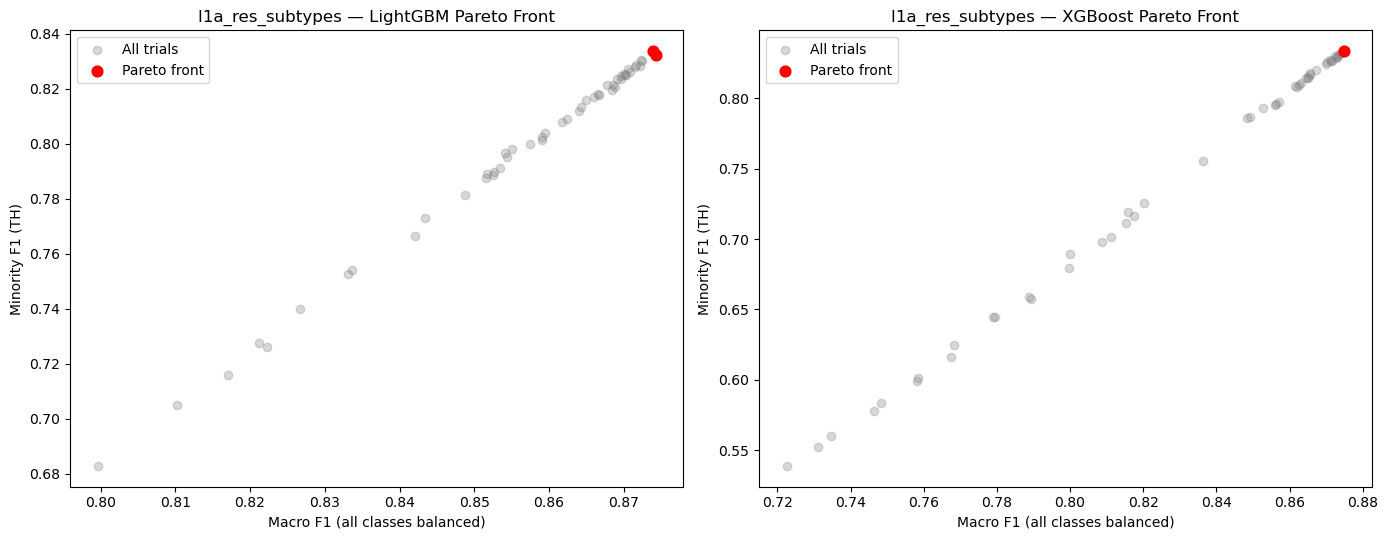

In [ ]:
print(f"Number of trials on the Pareto front: {len(study_lgb_multi.best_trials)}")

trial_with_highest_score_lgb = max(study_lgb_multi.best_trials, key=lambda t: t.values[1])
print("Trial with highest accuracy: ")
print(f"\tnumber: {trial_with_highest_score_lgb.number}")
print(f"\tparams: {trial_with_highest_score_lgb.params}")
print(f"\tvalues: {trial_with_highest_score_lgb.values}")

print(f"Number of trials on the Pareto front: {len(study_xgb_multi.best_trials)}")

trial_with_highest_score_xgb = max(study_xgb_multi.best_trials, key=lambda t: t.values[1])
print("Trial with highest accuracy: ")
print(f"\tnumber: {trial_with_highest_score_xgb.number}")
print(f"\tparams: {trial_with_highest_score_xgb.params}")
print(f"\tvalues: {trial_with_highest_score_xgb.values}")

# Plot the Pareto Front
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, study, name in [(axes[0], study_lgb_multi, 'LightGBM'), (axes[1], study_xgb_multi, 'XGBoost')]:
    all_macro    = [t.values[0] for t in study.trials if t.values is not None]
    all_minority = [t.values[1] for t in study.trials if t.values is not None]
    pareto_macro    = [t.values[0] for t in study.best_trials]
    pareto_minority = [t.values[1] for t in study.best_trials]

    ax.scatter(all_macro, all_minority, alpha=0.3, color='gray', label='All trials')
    ax.scatter(pareto_macro, pareto_minority, color='red', s=60, label='Pareto front', zorder=5)

    # Sort pareto points to draw a connecting line
    pareto_pts = sorted(zip(pareto_macro, pareto_minority))
    ax.plot(*zip(*pareto_pts), color='red', linestyle='--', alpha=0.5, linewidth=1)

    ax.set_xlabel('Macro F1 (all classes balanced)')
    ax.set_ylabel(f'Minority F1 ({classes[minority_class_idx]})')
    ax.set_title(f'{LEVEL} — {name} Pareto Front')
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Select a trial from the Pareto front — stated selection rule
# Rule: maximize minority F1, subject to macro F1 not dropping more than
# MAX_MACRO_DROP below the single best macro-F1 trial on the front.
MAX_MACRO_DROP = 0.01

best_macro_on_front = max(t.values[0] for t in study_lgb_multi.best_trials)
eligible_trials = [
    t for t in study_lgb_multi.best_trials
    if t.values[0] >= best_macro_on_front - MAX_MACRO_DROP
]
selected_trial = max(eligible_trials, key=lambda t: t.values[1])  # highest minority F1 among eligible

print(f"Selected LightGBM trial #{selected_trial.number}")
print(f"  Macro F1    : {selected_trial.values[0]:.4f}  (best on front: {best_macro_on_front:.4f})")
print(f"  Minority F1 : {selected_trial.values[1]:.4f}")
print(f"  Per-class F1: {dict(zip(classes, selected_trial.user_attrs['f1_per_class']))}")
print(f"  Params      : {selected_trial.params}")

best_lgb_params = selected_trial.params



# Select a trial from the XGBoost Pareto front — same rule as LightGBM

best_macro_on_front_xgb = max(t.values[0] for t in study_xgb_multi.best_trials)
eligible_trials_xgb = [
    t for t in study_xgb_multi.best_trials
    if t.values[0] >= best_macro_on_front_xgb - MAX_MACRO_DROP
]
selected_trial_xgb = max(eligible_trials_xgb, key=lambda t: t.values[1])

print(f"Selected XGBoost trial #{selected_trial_xgb.number}")
print(f"  Macro F1    : {selected_trial_xgb.values[0]:.4f}  (best on front: {best_macro_on_front_xgb:.4f})")
print(f"  Minority F1 : {selected_trial_xgb.values[1]:.4f}")
print(f"  Per-class F1: {dict(zip(classes, selected_trial_xgb.user_attrs['f1_per_class']))}")
print(f"  Params      : {selected_trial_xgb.params}")

best_xgb_params = selected_trial_xgb.params

Selected LightGBM trial #4
  Macro F1    : 0.8739  (best on front: 0.8743)
  Minority F1 : 0.8336
  Per-class F1: {'MFH': 0.8896115103940129, 'SFH': 0.8984425387573752, 'TH': 0.8336153065304992}
  Params      : {'minority_boost': 1.4491335820137876, 'learning_rate': 0.07143768406941398, 'num_leaves': 194, 'min_child_samples': 42, 'subsample': 0.7569392655737687, 'colsample_bytree': 0.7219974784450173, 'reg_alpha': 1.153814682105072, 'reg_lambda': 0.8034649961038726, 'min_split_gain': 0.024869374947388403}
Selected XGBoost trial #7
  Macro F1    : 0.8749  (best on front: 0.8749)
  Minority F1 : 0.8335
  Per-class F1: {'MFH': 0.8912310811839528, 'SFH': 0.90005254735233, 'TH': 0.833450071565612}
  Params      : {'minority_boost': 2.410696272133217, 'learning_rate': 0.032479939480004674, 'max_depth': 11, 'subsample': 0.7183193614340558, 'colsample_bytree': 0.7305212759063892, 'alpha': 0.26901532494526537, 'lambda': 1.3248236250565142, 'gamma': 0.0010705422769302349, 'min_child_weight': 3}


In [ ]:
# Train Final Model with Selected Pareto-Front Params
final_minority_boost_lgb = best_lgb_params.pop('minority_boost', None)  # not a model param, remove before passing to LGBMClassifier
if final_minority_boost_lgb is None:
    raise ValueError("Selected LightGBM trial does not have 'minority_boost' parameter.")
final_sample_weights_lgb = get_sample_weights(y_train, minority_boost=final_minority_boost_lgb)

final_minority_boost_xgb = best_xgb_params.pop('minority_boost', None)  # not a model param
if final_minority_boost_xgb is None:
    raise ValueError("Selected XGBoost trial does not have 'minority_boost' parameter.")
final_sample_weights_xgb = get_sample_weights(y_train, minority_boost=final_minority_boost_xgb)



In [ ]:
# save the best hyperparameters for reference
with open(os.path.join(MODEL_DIR, f'{LEVEL}_best_hyperparameters.json'), 'w') as f:
    json.dump({'lightgbm': best_lgb_params, 'xgboost': best_xgb_params}, f, indent=4)


trained_models = {}


# Train LightGBM Natively
print(f"\n{'='*60}\nTraining full-scale LIGHTGBM...\n{'='*60}")
lgb_params = {
    'objective': 'multiclass', 'num_class': len(classes), 'metric': 'multi_logloss', 
    'boosting_type': 'gbdt', 'n_estimators': 25000,  'importance_type': 'gain',
    'n_jobs': -1, 'random_state': 42, 'verbosity': -1, **best_lgb_params, 'max_depth': -1
}
model_lgb = lgb.LGBMClassifier(**lgb_params)
model_lgb.fit(X_train, y_train, eval_set=[(X_val, y_val)],
              sample_weight=final_sample_weights_lgb, callbacks=[lgb.early_stopping(150), lgb.log_evaluation(200)])

save_path_lgb = os.path.join(MODEL_DIR, f'{LEVEL}_lightgbm_optimized.pkl')
joblib.dump(model_lgb, save_path_lgb)
trained_models['lightgbm'] = model_lgb


# Train XGBoost with the explicit sample_weight array injected
print(f"\n{'='*60}\nTraining full-scale XGBOOST...\n{'='*60}")
xgb_params = {
    'objective': 'multi:softprob', 'num_class': len(classes), 'eval_metric': 'mlogloss',
    'n_estimators': 25000, 'tree_method': 'hist', 'importance_type': 'gain',
    'early_stopping_rounds': 150, 'n_jobs': -1, 'random_state': 42, **best_xgb_params
}
model_xgb = xgb.XGBClassifier(**xgb_params)
model_xgb.fit(
    X_train, y_train, 
    sample_weight=final_sample_weights_xgb,
    eval_set=[(X_val, y_val)], 
    verbose=200
)

save_path_xgb = os.path.join(MODEL_DIR, f'{LEVEL}_xgboost_optimized.pkl')
joblib.dump(model_xgb, save_path_xgb)
trained_models['xgboost'] = model_xgb


Training full-scale LIGHTGBM...


Training until validation scores don't improve for 150 rounds
[200]	valid_0's multi_logloss: 0.401076
[400]	valid_0's multi_logloss: 0.359498
[600]	valid_0's multi_logloss: 0.331673
[800]	valid_0's multi_logloss: 0.31043
[1000]	valid_0's multi_logloss: 0.29363
[1200]	valid_0's multi_logloss: 0.280115
[1400]	valid_0's multi_logloss: 0.268688
[1600]	valid_0's multi_logloss: 0.259259
[1800]	valid_0's multi_logloss: 0.251247
[2000]	valid_0's multi_logloss: 0.244266
[2200]	valid_0's multi_logloss: 0.238215
[2400]	valid_0's multi_logloss: 0.233091
[2600]	valid_0's multi_logloss: 0.228327
[2800]	valid_0's multi_logloss: 0.224036
[3000]	valid_0's multi_logloss: 0.22004
[3200]	valid_0's multi_logloss: 0.216435
[3400]	valid_0's multi_logloss: 0.213302
[3600]	valid_0's multi_logloss: 0.210442
[3800]	valid_0's multi_logloss: 0.207914
[4000]	valid_0's multi_logloss: 0.205507
[4200]	valid_0's multi_logloss: 0.203392
[4400]	valid_0's multi_logloss: 0.201334
[4600]	valid_0's multi_logloss: 0.199522
[4


FINAL TEST SET EVALUATION

lightgbm — VAL (Decision Threshold: 0.500)
  Macro F1    : 0.9347
  Weighted F1 : 0.9333
              precision    recall  f1-score   support

         MFH     0.9404    0.9172    0.9287     73893
         SFH     0.9253    0.9473    0.9362     82110
          TH     0.9429    0.9359    0.9394     16399

    accuracy                         0.9333    172402
   macro avg     0.9362    0.9335    0.9347    172402
weighted avg     0.9335    0.9333    0.9333    172402


lightgbm — TEST (Decision Threshold: 0.500)
  Macro F1    : 0.9358
  Weighted F1 : 0.9344
              precision    recall  f1-score   support

         MFH     0.9419    0.9181    0.9298    147407
         SFH     0.9263    0.9487    0.9374    164720
          TH     0.9438    0.9362    0.9400     32622

    accuracy                         0.9345    344749
   macro avg     0.9373    0.9344    0.9358    344749
weighted avg     0.9346    0.9345    0.9344    344749



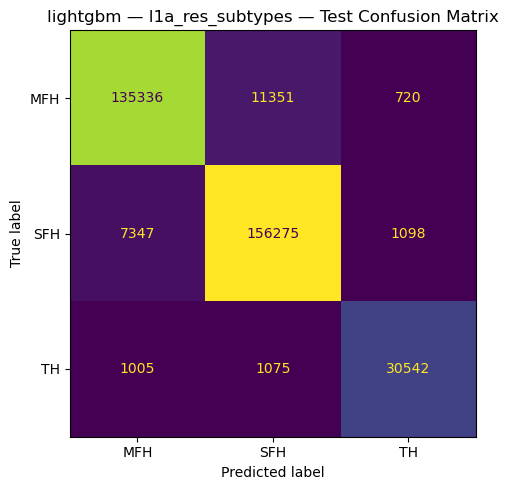


xgboost — VAL (Decision Threshold: 0.500)
  Macro F1    : 0.9371
  Weighted F1 : 0.9350
              precision    recall  f1-score   support

         MFH     0.9427    0.9175    0.9299     73893
         SFH     0.9263    0.9495    0.9377     82110
          TH     0.9460    0.9413    0.9437     16399

    accuracy                         0.9350    172402
   macro avg     0.9383    0.9361    0.9371    172402
weighted avg     0.9352    0.9350    0.9350    172402


xgboost — TEST (Decision Threshold: 0.500)
  Macro F1    : 0.9376
  Weighted F1 : 0.9360
              precision    recall  f1-score   support

         MFH     0.9438    0.9187    0.9311    147407
         SFH     0.9276    0.9507    0.9390    164720
          TH     0.9455    0.9399    0.9427     32622

    accuracy                         0.9360    344749
   macro avg     0.9390    0.9364    0.9376    344749
weighted avg     0.9362    0.9360    0.9360    344749



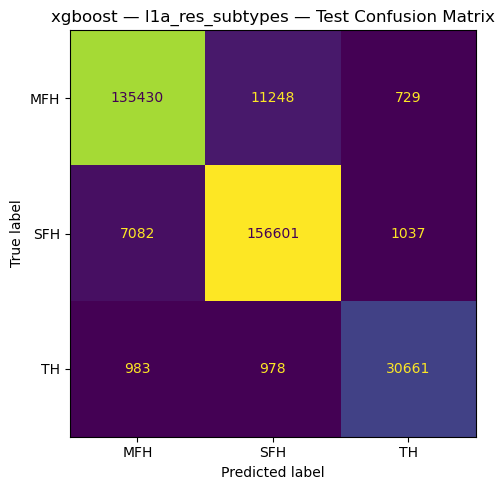

In [24]:
print(f"\n{'='*60}\nFINAL TEST SET EVALUATION\n{'='*60}")
for model_name, model in trained_models.items():
    all_results[model_name] = evaluate(model, X_val, y_val, X_test, y_test, classes, model_name, LEVEL)



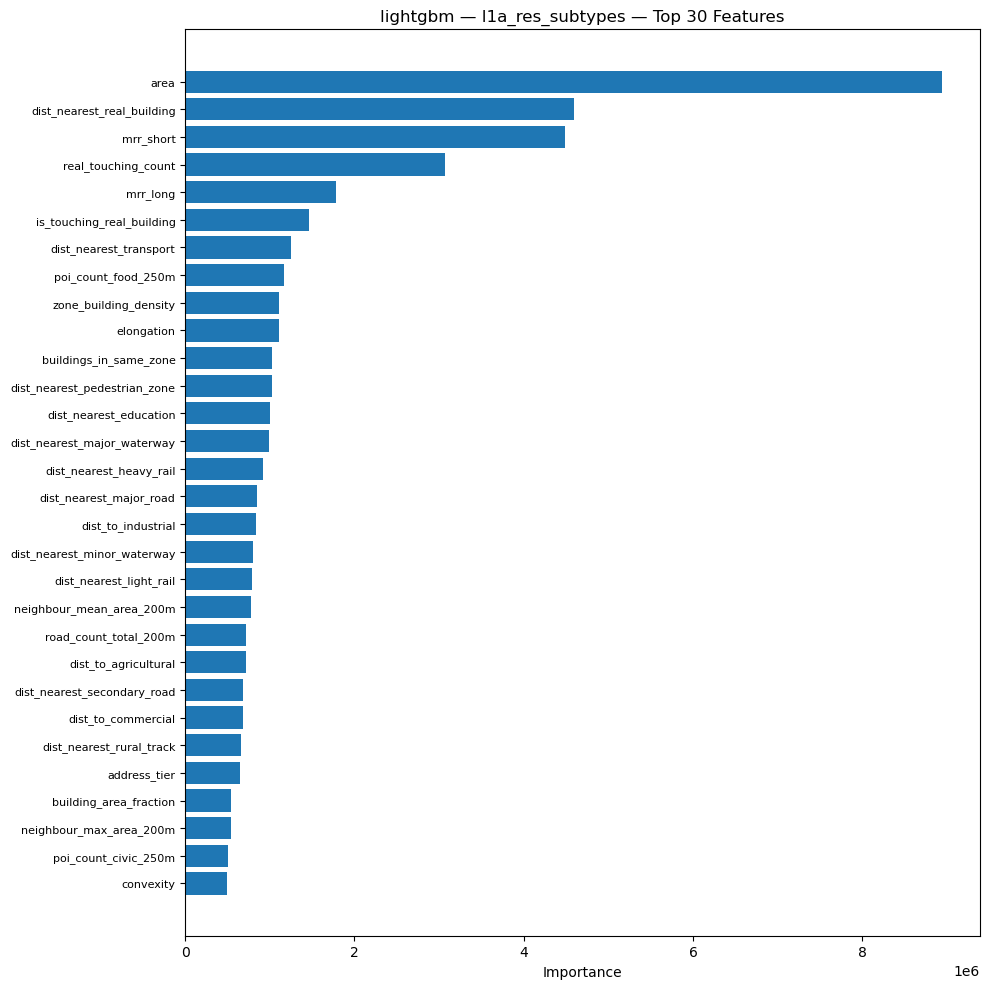

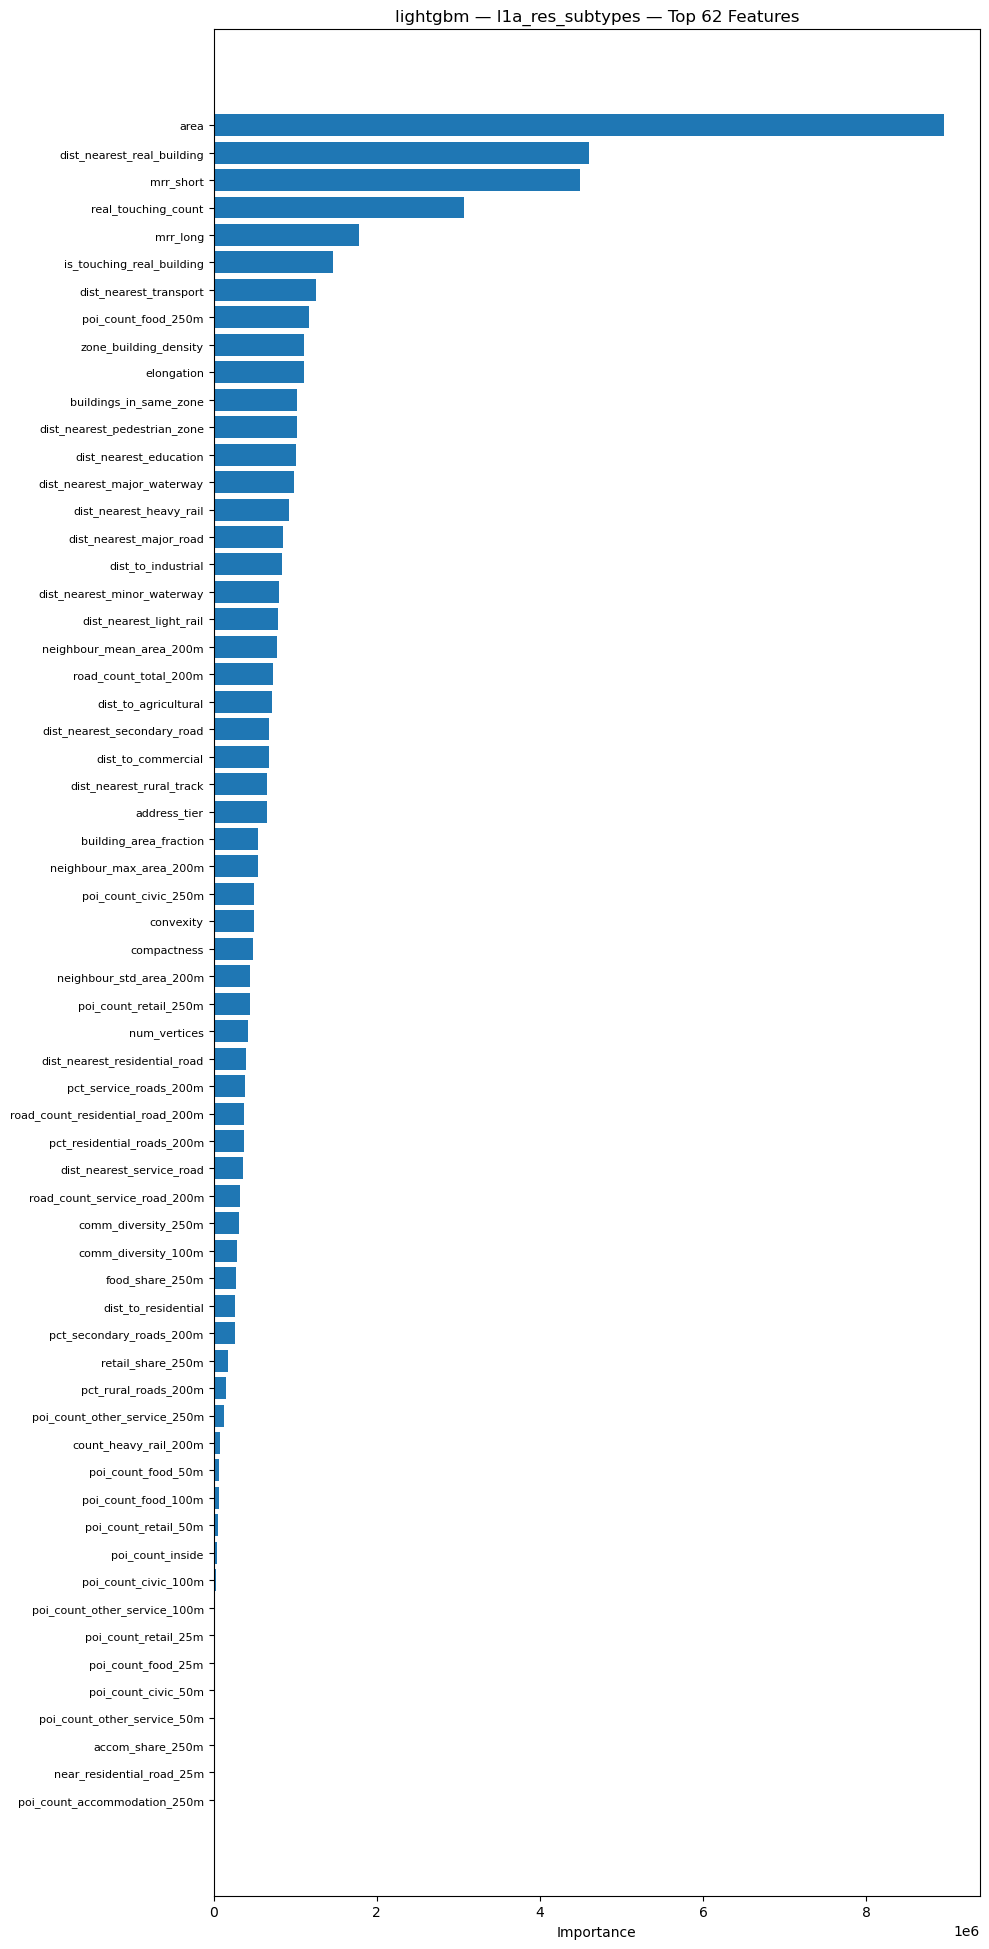

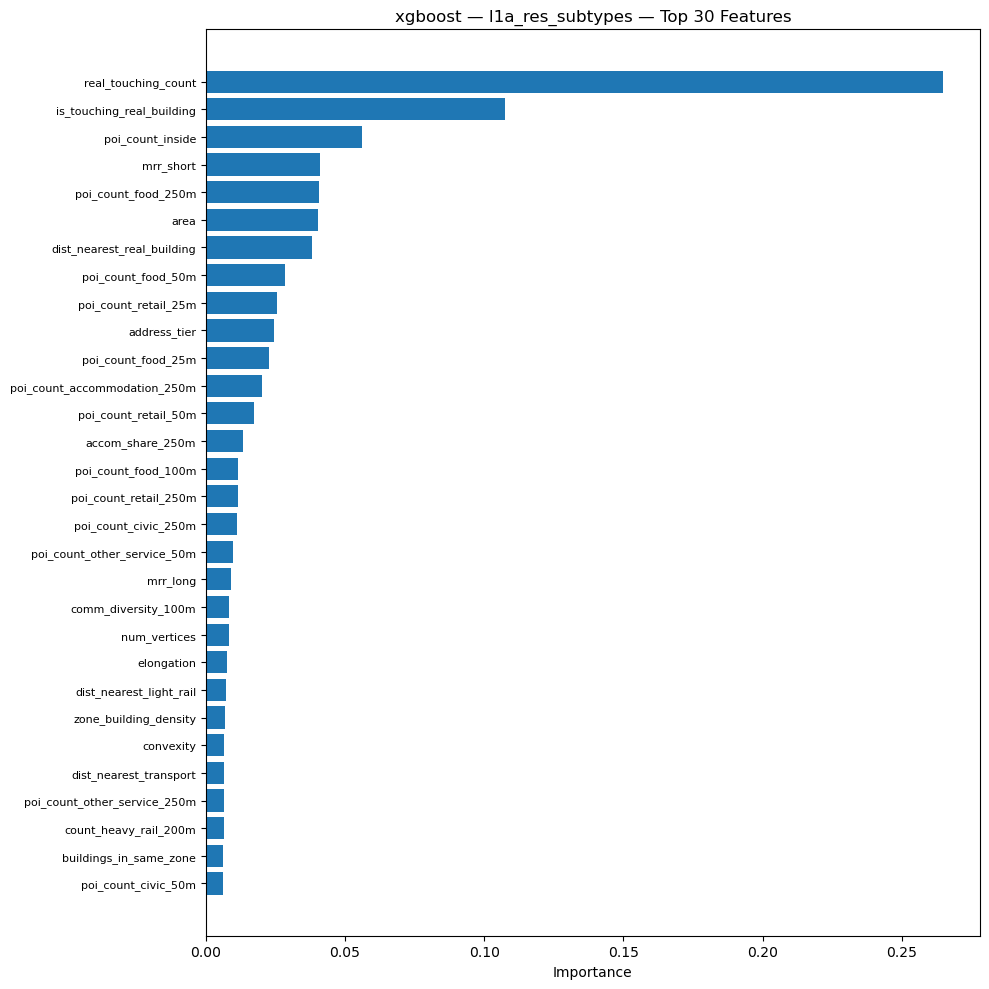

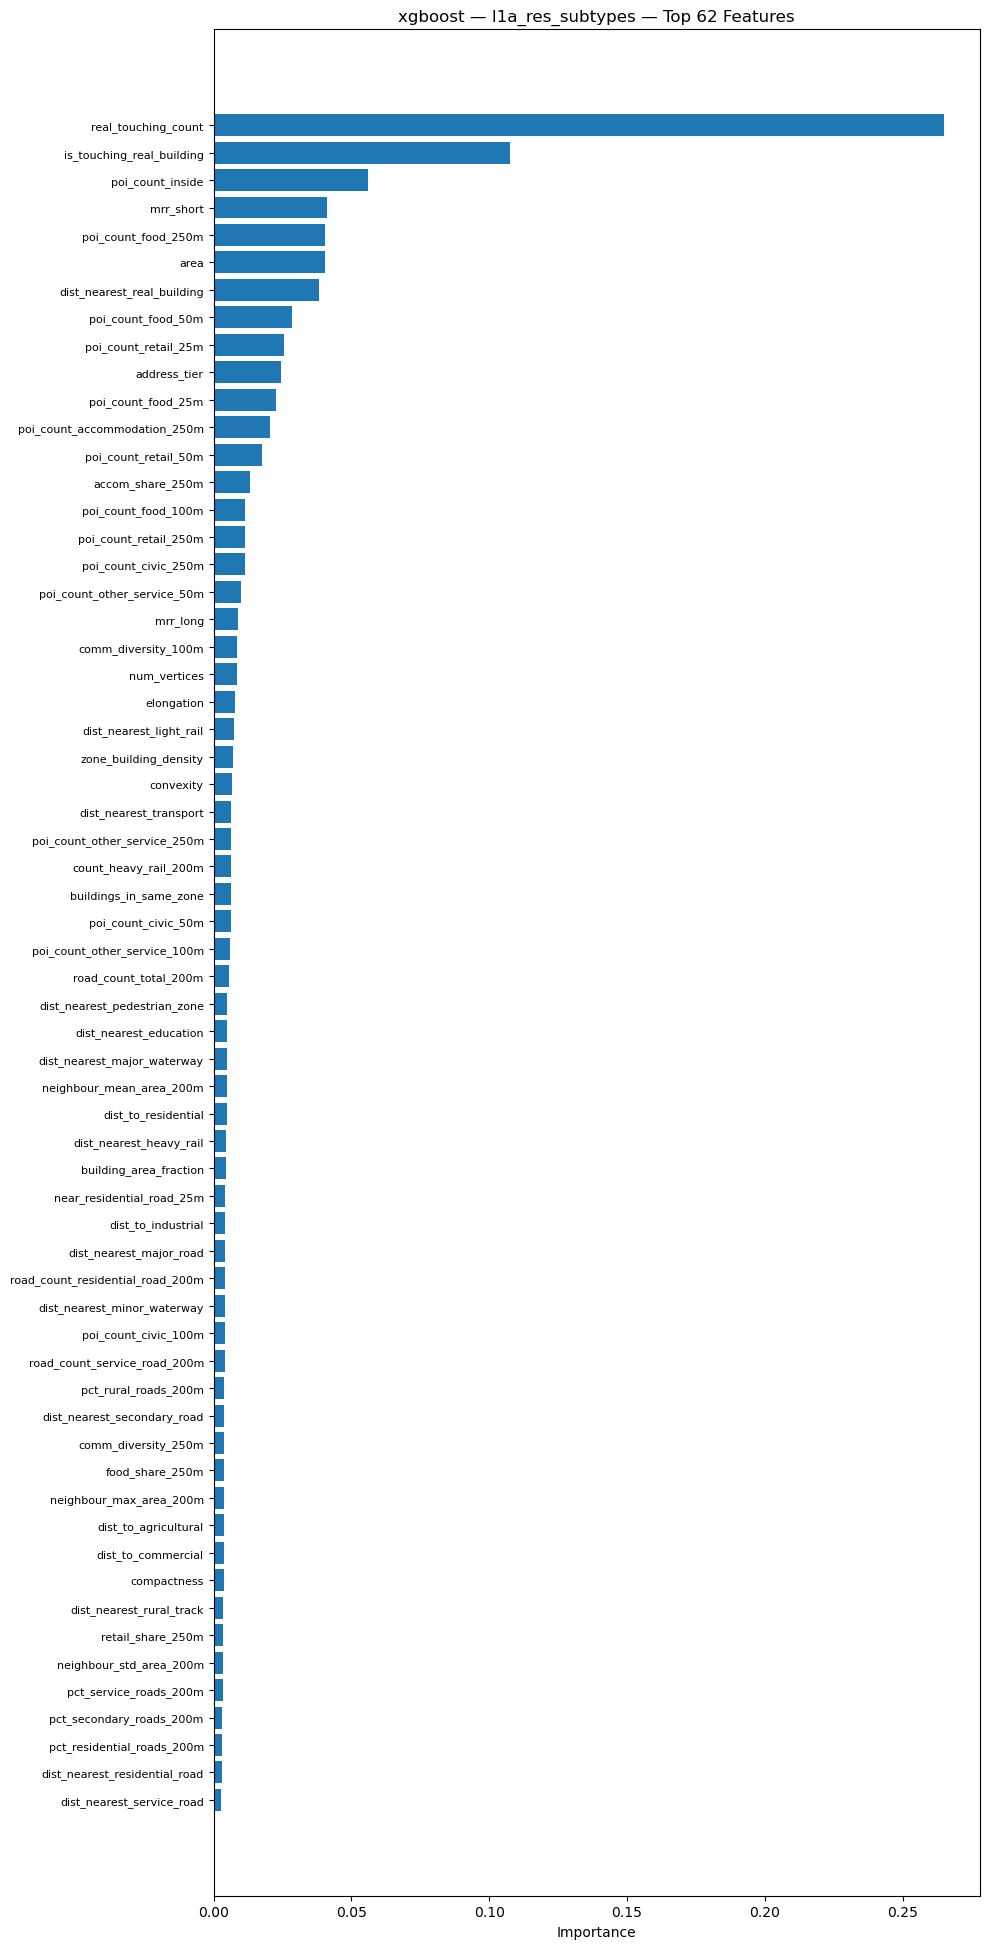

In [ ]:
# Feature Importance (trees only)
def plot_feature_importance(model, model_name, feature_cols, level, top_n=30):
    if hasattr(model, 'feature_importances_'):
        imp = model.feature_importances_
    else:
        return

    idx  = np.argsort(imp)[::-1][:top_n]
    fig, ax = plt.subplots(figsize=(10, top_n * 0.3 + 1))
    ax.barh(range(top_n), imp[idx][::-1])
    ax.set_yticks(range(top_n))
    ax.set_yticklabels([feature_cols[i] for i in idx[::-1]], fontsize=8)
    ax.set_title(f'{model_name} — {level} — Top {top_n} Features')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_DIR, f'{level}_{model_name}_importance.png'), dpi=120)
    plt.show()

for model_name, model in trained_models.items():
    plot_feature_importance(model, model_name, feature_cols, LEVEL)
    plot_feature_importance(model, model_name, feature_cols, LEVEL, len(feature_cols))

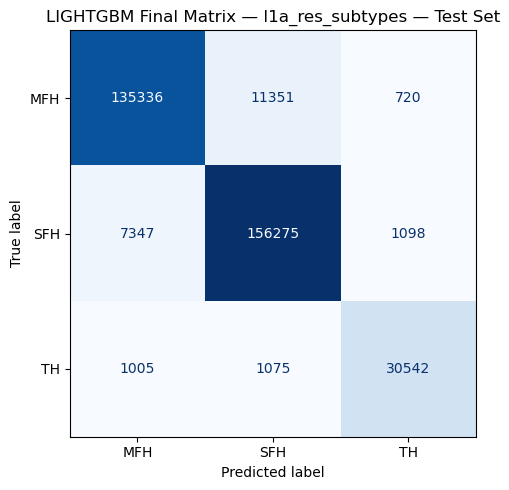

In [26]:
# Generate Visual Confusion Matrix for LightGBM
best_model_name = 'lightgbm'
best_model = trained_models[best_model_name]
final_preds = best_model.predict(X_test).astype(int)

cm = confusion_matrix(y_test, final_preds)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=classes).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'{best_model_name.upper()} Final Matrix — {LEVEL} — Test Set')
plt.tight_layout()
plt.show()

In [ ]:

print(f"\n{'='*60}")
print(f"MODEL COMPARISON — {LEVEL} — TEST SET")
print(f"{'='*60}")
print(f"{'Model':<20} {'Macro F1':>10} {'Weighted F1':>13}")
print("-" * 45)

for model_name, res in all_results.items():
    mf1 = res['test']['macro_f1']
    wf1 = res['test']['weighted_f1']
    print(f"{model_name:<20} {mf1:>10.4f} {wf1:>13.4f}")

# Save results to JSON for later aggregation
results_path = os.path.join(MODEL_DIR, f'{LEVEL}_results.json')
# Make results JSON-serialisable
serialisable = {
    m: {s: {k: v for k, v in r.items() if k != 'report'}
        for s, r in res.items()}
    for m, res in all_results.items()
}
with open(results_path, 'w') as f:
    json.dump(serialisable, f, indent=2)
print(f"\nResults saved → {results_path}")


MODEL COMPARISON — l1a_res_subtypes — TEST SET
Model                  Macro F1   Weighted F1
---------------------------------------------
lightgbm                 0.9358        0.9344
xgboost                  0.9376        0.9360

Results saved → /fast/home/o-olajuyigbe/osm_project/data/models/l1a_res_subtypes_results.json


In [28]:
BEST_MODEL = 'xgboost'  # Options: 'lightgbm' or 'xgboost'
# ────────────────────────────────────────────────────────────────────

print(f"Preparing final production rollout strictly for the winning model: {BEST_MODEL.upper()}")

X_production_train = np.vstack([X_train, X_test])
y_production_train = np.concatenate([y_train, y_test])

X_production_val = X_val
y_production_val = y_val

print(f"Expanded Training Pool Size : {X_production_train.shape[0]:,} rows (95%)")
print(f"Early Stopping Validation Size: {X_production_val.shape[0]:,} rows (5%)")

production_sample_weights = get_sample_weights(
    y_production_train,
    minority_boost=final_minority_boost_lgb if BEST_MODEL == 'lightgbm' else final_minority_boost_xgb
)

if BEST_MODEL == 'lightgbm':
    prod_model = lgb.LGBMClassifier(
        objective='multiclass', num_class=len(classes), metric='multi_logloss', boosting_type='gbdt',
        n_estimators=25000, importance_type='gain',  
        n_jobs=-1, random_state=42, verbosity=-1, **best_lgb_params, max_depth=-1
    )
    prod_model.fit(
        X_production_train, y_production_train,
        sample_weight=production_sample_weights, # Add this line
        eval_set=[(X_production_val, y_production_val)],
        callbacks=[lgb.early_stopping(150), lgb.log_evaluation(200)]
    )
    
elif BEST_MODEL == 'xgboost':
    # Re-calculate balanced scaling array weights on the combined 95% production data matrix
   
    prod_model = xgb.XGBClassifier(
        objective='multi:softprob', num_class=len(classes), eval_metric='mlogloss',
        n_estimators=25000, tree_method='hist',  early_stopping_rounds=150, importance_type='gain',
        n_jobs=-1, random_state=42, **best_xgb_params
    )
    prod_model.fit(
        X_production_train, y_production_train,
        sample_weight=production_sample_weights, 
        eval_set=[(X_production_val, y_production_val)], 
        verbose=200
    )

production_save_path = os.path.join(MODEL_DIR, f'{LEVEL}_xgb_PRODUCTION_FINAL.pkl')
joblib.dump(prod_model, production_save_path)
print(f"\n{'='*60}\n✅ ULTIMATE PRODUCTION MODEL DEPLOYED!\n   Saved model to: {production_save_path}\n{'='*60}")

Preparing final production rollout strictly for the winning model: XGBOOST
Expanded Training Pool Size : 3,273,753 rows (95%)
Early Stopping Validation Size: 172,402 rows (5%)
[0]	validation_0-mlogloss:1.35918
[200]	validation_0-mlogloss:0.47238
[400]	validation_0-mlogloss:0.41235
[600]	validation_0-mlogloss:0.36916
[800]	validation_0-mlogloss:0.33761
[1000]	validation_0-mlogloss:0.31294
[1200]	validation_0-mlogloss:0.29419
[1400]	validation_0-mlogloss:0.27843
[1600]	validation_0-mlogloss:0.26539
[1800]	validation_0-mlogloss:0.25447
[2000]	validation_0-mlogloss:0.24503
[2200]	validation_0-mlogloss:0.23688
[2400]	validation_0-mlogloss:0.22972
[2600]	validation_0-mlogloss:0.22357
[2800]	validation_0-mlogloss:0.21815
[3000]	validation_0-mlogloss:0.21322
[3200]	validation_0-mlogloss:0.20863
[3400]	validation_0-mlogloss:0.20470
[3600]	validation_0-mlogloss:0.20131
[3800]	validation_0-mlogloss:0.19827
[4000]	validation_0-mlogloss:0.19541
[4200]	validation_0-mlogloss:0.19284
[4400]	validation